<style>
@media print {
  @page {
    size: A4;
    margin: 1.5cm;
  }

  .jp-Cell,
  .jp-OutputArea-output,
  .jp-RenderedImage,
  .output_png {
    break-inside: avoid;
    page-break-inside: avoid;
  }

  .jp-RenderedImage img,
  .output_png img {
    max-width: 100% !important;
    height: auto !important;
  }
}
</style>

# Análise exploratória dos preços de soja e milho

Este notebook caracteriza os atributos do conjunto de preços agrícolas, avalia medidas de localidade, investiga o espalhamento e possíveis outliers e calcula correlação e covariância entre soja e milho.

**Fonte e contexto:** dados diários de 02/01/2014 a 30/12/2015, com soja comercializada no Paraná e milho comercializado na região de Campinas-SP. Os preços estão em R$ por saca de 60 kg. A análise é descritiva e não implica causalidade.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
sns.set_theme(style='whitegrid', palette='Set2')
DATA_PATH = Path('dados/soja_milho.xlsx')
assert DATA_PATH.exists(), f'Arquivo não encontrado: {DATA_PATH}'

## 1. Caracterização inicial


In [11]:
precos = pd.read_excel(DATA_PATH, sheet_name='precos', skiprows=7)
precos['Data'] = pd.to_datetime(precos['Data'], dayfirst=True)

print(f'Dimensões: {precos.shape[0]} linhas x {precos.shape[1]} colunas')
print(f'Período: {precos["Data"].min():%d/%m/%Y} a {precos["Data"].max():%d/%m/%Y}')
display(precos.head())
display(precos.tail())
display(precos.dtypes.rename('tipo'))

Dimensões: 498 linhas x 6 colunas
Período: 02/01/2014 a 30/12/2015


,Observação,Data,Mês,Ano - Safra,Preços - Milho,Preços - Soja
0,1,2014-01-02,1,2014,26.64,72.18
1,2,2014-01-03,1,2014,27.00,71.42
2,3,2014-01-06,1,2014,27.29,71.38
3,4,2014-01-07,1,2014,27.49,70.31
4,5,2014-01-08,1,2014,27.16,70.14


,Observação,Data,Mês,Ano - Safra,Preços - Milho,Preços - Soja
493,494,2015-12-22,12,2015,36.23,78.61
494,495,2015-12-23,12,2015,36.26,78.21
495,496,2015-12-28,12,2015,36.29,77.59
496,497,2015-12-29,12,2015,36.55,78.55
497,498,2015-12-30,12,2015,36.83,78.07


Observação                 int64
Data              datetime64[us]
Mês                        int64
Ano - Safra                int64
Preços - Milho           float64
Preços - Soja            float64
Name: tipo, dtype: object

In [12]:
qualidade = pd.DataFrame({
'não nulos': precos.notna().sum(),
'nulos': precos.isna().sum(),
'valores únicos': precos.nunique(),
'tipo': precos.dtypes.astype(str)
})
print(f'Linhas duplicadas: {precos.duplicated().sum()}')
display(qualidade)

precos_numericos = ['Observação', 'Mês', 'Ano - Safra', 'Preços - Milho', 'Preços - Soja']
assert precos[precos_numericos].notna().all().all(), 'Há valores ausentes nos atributos numéricos.'
assert precos['Data'].is_monotonic_increasing, 'As datas não estão em ordem crescente.'

Linhas duplicadas: 0


,não nulos,nulos,valores únicos,tipo
Observação,498,0,498,int64
Data,498,0,498,datetime64[us]
Mês,498,0,12,int64
Ano - Safra,498,0,2,int64
Preços - Milho,498,0,393,float64
Preços - Soja,498,0,424,float64


### 1.1 Tipos dos atributos e qualidade dos dados

`Observação` é um identificador sequencial; `Data` é temporal; `Mês` e `Ano - Safra` são atributos de calendário/safra; `Preços - Milho` e `Preços - Soja` são quantitativos contínuos, em R$/saca de 60 kg. Não foram encontrados valores ausentes, duplicidades ou desordem temporal na validação acima.

### 1.2 Medidas de localidade


In [13]:
precos_analisados = precos[['Preços - Milho', 'Preços - Soja']].copy()
medidas_localidade = precos_analisados.agg(['mean', 'median', 'min', 'max'])
quartis = precos_analisados.quantile([0.25, 0.50, 0.75]).rename(index={0.25: 'Q1', 0.50: 'Mediana (Q2)', 0.75: 'Q3'})
resumo = pd.concat([medidas_localidade, quartis])
display(resumo)
display(precos_analisados.describe().T)

,Preços - Milho,Preços - Soja
mean,27.96,66.50
median,27.54,65.16
min,21.76,56.74
max,36.83,79.86
Q1,25.51,62.30
Mediana (Q2),27.54,65.16
Q3,30.32,69.19


,count,mean,std,min,25%,50%,75%,max
Preços - Milho,498.00,27.96,3.56,21.76,25.51,27.54,30.32,36.83
Preços - Soja,498.00,66.50,5.80,56.74,62.30,65.16,69.19,79.86


## 2. Espalhamento e identificação de outliers

Os preços serão avaliados por boxplots, histogramas e pelo critério do intervalo interquartil (IQR). Uma observação é marcada como outlier quando fica abaixo de `Q1 - 1,5*IQR` ou acima de `Q3 + 1,5*IQR`.

### 2.1 Boxplots dos preços

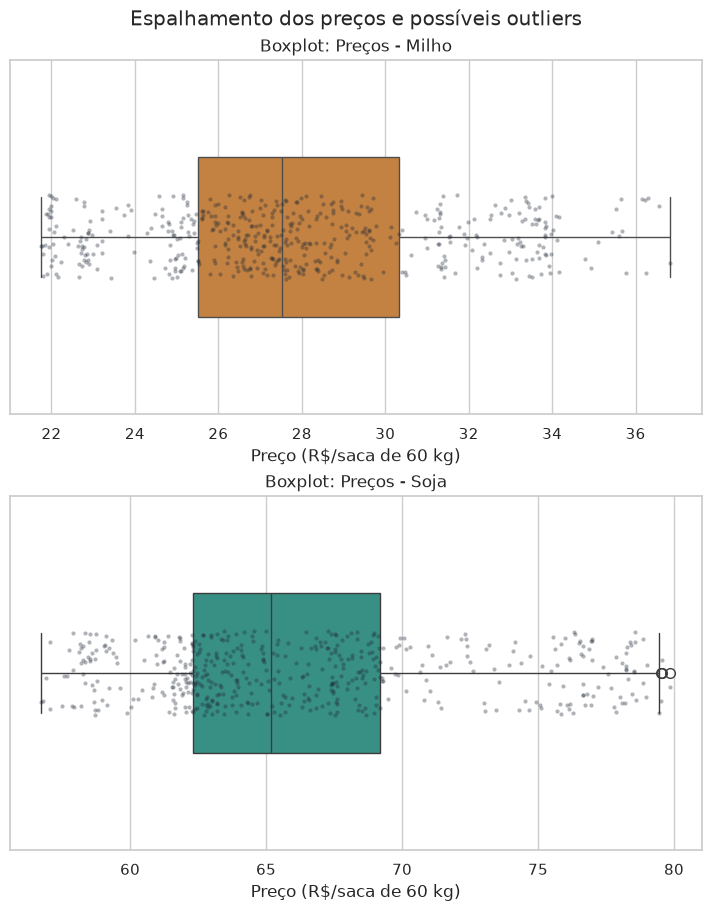

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(7, 9), constrained_layout=True)
for axis, column, color in zip(axes, precos_analisados.columns, ['#d9822b', '#2a9d8f']):
    sns.boxplot(x=precos_analisados[column], ax=axis, color=color, width=0.45, fliersize=7)
    sns.stripplot(x=precos_analisados[column], ax=axis, color='#1f2937', size=3, alpha=0.35, jitter=0.12)
    axis.set_title(f'Boxplot: {column}')
    axis.set_xlabel('Preço (R$/saca de 60 kg)')
    axis.set_ylabel('')
fig.suptitle('Espalhamento dos preços e possíveis outliers')
plt.show()

### 2.2 Histogramas e identificação pelo IQR


,Q1,Q3,IQR,limite inferior,limite superior,nº outliers,percentual
atributo,,,,,,,
Preços - Milho,25.51,30.32,4.81,18.30,37.53,0,0.00
Preços - Soja,62.30,69.19,6.89,51.97,79.52,3,0.60


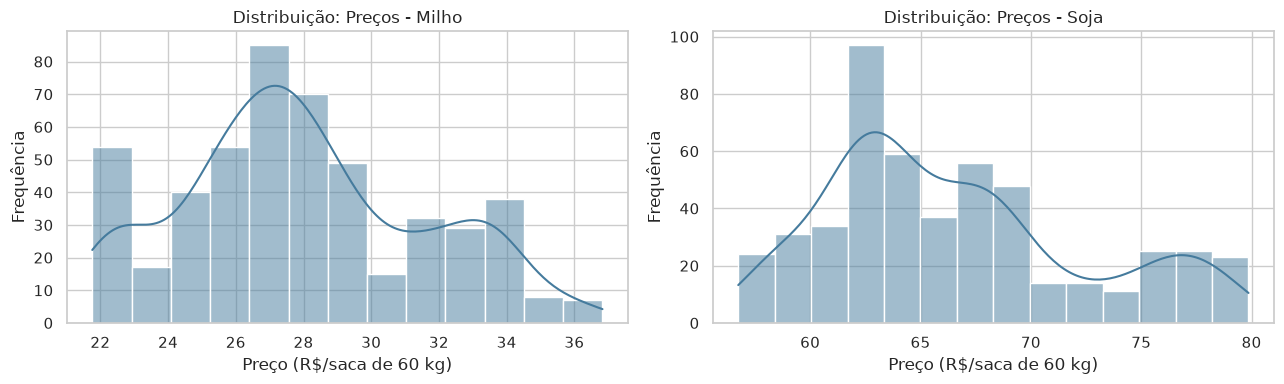

In [ ]:
def limites_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr

linhas_outliers = []
for column in precos_analisados.columns:
    q1, q3, iqr, inferior, superior = limites_iqr(precos_analisados[column])
    mascara = (precos_analisados[column] < inferior) | (precos_analisados[column] > superior)
    linhas_outliers.append({
        'atributo': column, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'limite inferior': inferior, 'limite superior': superior,
        'nº outliers': int(mascara.sum()), 'percentual': 100 * mascara.mean()
    })

tabela_outliers = pd.DataFrame(linhas_outliers).set_index('atributo')
display(tabela_outliers)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for axis, column in zip(axes, precos_analisados.columns):
    sns.histplot(precos_analisados[column], kde=True, ax=axis, color='#457b9d')
    axis.set_title(f'Distribuição: {column}')
    axis.set_xlabel('Preço (R$/saca de 60 kg)')
    axis.set_ylabel('Frequência')
plt.tight_layout()
plt.show()

## 3. Correlação e covariância


### 3.1 Associação entre os preços

Matriz de correlação de Pearson


,Preços - Milho,Preços - Soja
Preços - Milho,1.00,0.75
Preços - Soja,0.75,1.00


Matriz de covariância amostral


,Preços - Milho,Preços - Soja
Preços - Milho,12.70,15.49
Preços - Soja,15.49,33.69


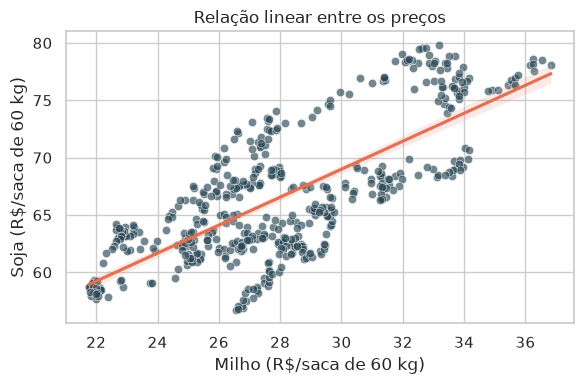

In [16]:
correlacao = precos_analisados.corr(method='pearson')
covariancia = precos_analisados.cov()
print('Matriz de correlação de Pearson')
display(correlacao)
print('Matriz de covariância amostral')
display(covariancia)

fig, axis = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=precos_analisados, x='Preços - Milho', y='Preços - Soja', alpha=0.65, ax=axis, color='#264653')
sns.regplot(data=precos_analisados, x='Preços - Milho', y='Preços - Soja', scatter=False, ax=axis, color='#e76f51')
axis.set_title('Relação linear entre os preços')
axis.set_xlabel('Milho (R$/saca de 60 kg)')
axis.set_ylabel('Soja (R$/saca de 60 kg)')
plt.tight_layout()
plt.show()

### 3.2 Interpretação dos resultados

In [ ]:
print(f'Conclusão quantitativa: a correlação de Pearson é {pearson:.3f}')
print(f'A covariância amostral entre milho e soja é {covariancia_cruzada:.3f} (R$² por saca²).')
print('A interpretação deve permanecer restrita a este período, locais e definição de preços.')

Conclusão quantitativa: a correlação de Pearson é 0.749
A covariância amostral entre milho e soja é 15.494 (R$² por saca²).


#### Interpretação detalhada dos resultados

A análise foi realizada sobre **498 observações diárias**, abrangendo o período de 02/01/2014 a 30/12/2015. Os preços médios foram de aproximadamente **R$ 27,96 por saca de milho** e **R$ 66,50 por saca de soja**. As medianas foram, respectivamente, **R$ 27,54** e **R$ 65,16**. Como as médias são um pouco superiores às medianas, há indicação de uma leve assimetria à direita, especialmente no preço da soja, mas essa diferença não deve ser interpretada isoladamente como evidência de um comportamento anormal.

Quanto ao espalhamento, o desvio-padrão do milho foi de aproximadamente **R$ 3,56**, enquanto o da soja foi de **R$ 5,80**. Em valores absolutos, a soja apresentou maior variabilidade. A comparação também pode ser feita em termos relativos: o desvio-padrão representa cerca de **12,7% da média do milho** e **8,7% da média da soja**. Portanto, embora a soja varie mais em reais por saca, o milho apresenta maior dispersão proporcional ao seu nível médio de preço.

A correlação de Pearson obtida foi **0,749**, indicando uma associação linear positiva forte entre os preços no período observado. Em termos descritivos, os dias com preços de milho mais elevados tendem a coincidir com dias em que os preços de soja também estão mais elevados. O diagrama de dispersão e a reta ajustada ajudam a visualizar essa tendência, embora os pontos não estejam perfeitamente alinhados: ainda existe variação dos preços de soja que não é explicada apenas pela variação do milho.

A covariância amostral foi **15,494**. O valor positivo é coerente com a correlação positiva, pois indica que, em geral, desvios acima da média em uma série ocorrem junto com desvios acima da média na outra, e o mesmo vale para desvios abaixo da média. Diferentemente da correlação, a covariância depende das escalas utilizadas e é expressa em unidades combinadas de preço; por isso, seu valor numérico não deve ser usado sozinho para comparar a força da relação com outros conjuntos de dados.

Esses resultados mostram uma associação relevante entre as duas séries, mas não demonstram que a variação do preço de um produto cause a variação do outro. A relação pode estar associada a fatores comuns, como condições climáticas, custos de produção, câmbio, demanda, exportações, sazonalidade e condições gerais do mercado agrícola. Além disso, como as séries correspondem a localidades específicas e a um intervalo de apenas dois anos, a intensidade observada pode mudar em outros períodos ou regiões.

Assim, a conclusão mais adequada é que os preços de soja e milho apresentaram comportamento **positivamente associado e relativamente alinhado** durante o período analisado. Para aprofundar a investigação, seria necessário analisar a evolução temporal, separar os dados por safra ou mês, avaliar correlações defasadas e verificar se a associação permanece após controlar tendências e possíveis outliers.